# RB-F07 v1：較正を通した市場クオート感応度

**問い：** 曲線の柱の感応度と、取引する市場クオートの感応度はどう違うか。

合成の単一曲線を預金・FRA・parスワップの5クオートで厳密に較正する。
ポートフォリオは4年receiver swap（元本1,000万・固定3.2%）と1.5年割引債の売り300万。
年率は単利、柱は連続複利zero、通貨の単位は仮想通貨単位。
市場データ・予測力・取引収益の評価ではない。

計算は非公開 `hullkit._quote_risk`。このnotebookは保存済み `reference.json` の表示だけを行う。
数値例、独立brentq、複素ステップ、不変性の検証は生成器・テストで実行する。
設計と出典は同じディレクトリの `README.md` を参照。


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

data = json.loads(Path("reference.json").read_text(encoding="utf-8"))
base = data["base"]
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
display(Markdown(f"**PV：{base['pv']:,.2f}**。Newton {base['iterations']}回、"
                 f"brentqとのzero差 {base['brentq_zero_max_abs_error']:.2e}。"))


**PV：-2,980,843.07**。Newton 3回、brentqとのzero差 4.20e-16。

## 1. 柱の感応度を、そのまま市場リスクと読めるか

較正残差を $F(z,q)=m(z)-q=0$、$J=\partial m/\partial z$ とすると、

$$\frac{dz}{dq}=J^{-1},\qquad J^\top\lambda=\nabla_z V,\qquad\frac{dV}{dq}=\lambda.$$

6か月の柱を固定して動かしてもポートフォリオ価格は変わらない。
しかし6か月預金のクオートを動かして再較正すると、FRAを通じて1年の柱も動く。
したがって、6か月の**柱は0/bp、預金クオートは約+106.30/bp**になる。
ここでは価格の直接クオート依存 $\partial V/\partial q=0$ と仮定する。


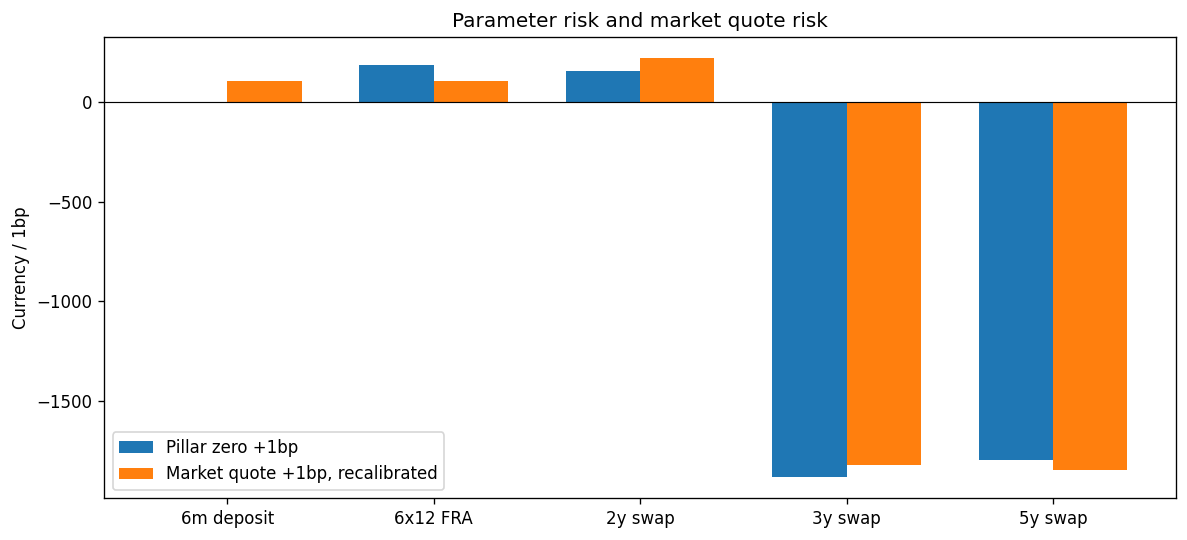

In [2]:
x = np.arange(len(data["labels"]))
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x - 0.18, base["parameter_risk_per_bp"], width=0.36, label="Pillar zero +1bp")
ax.bar(x + 0.18, base["quote_risk_per_bp"], width=0.36, label="Market quote +1bp, recalibrated")
ax.axhline(0, color="black", linewidth=0.7)
ax.set_xticks(x, data["labels"])
ax.set_ylabel("Currency / 1bp")
ax.set_title("Parameter risk and market quote risk")
ax.legend()
fig.tight_layout()
plt.show()


## 2. 再較正の中央差分は、どの幅で信頼できるか

解析感応度と、別の逐次brentqでクオートを上下に動かして再較正した中央差分を比較する。
十分大きい幅では打切り誤差がおよそ $h^2$ で減少する。
小さすぎる幅では価格の引き算と較正の丸め誤差が効く。
**小さい幅の点の上下は環境に依存する観測で、特定のV字を合否条件にしない。**

複素ステップは滑らかなクオート関数と割引ポートフォリオの微分を別に求め、
そこから随伴感応度を求めた比較。max・abs・行使境界への適用は主張しない。


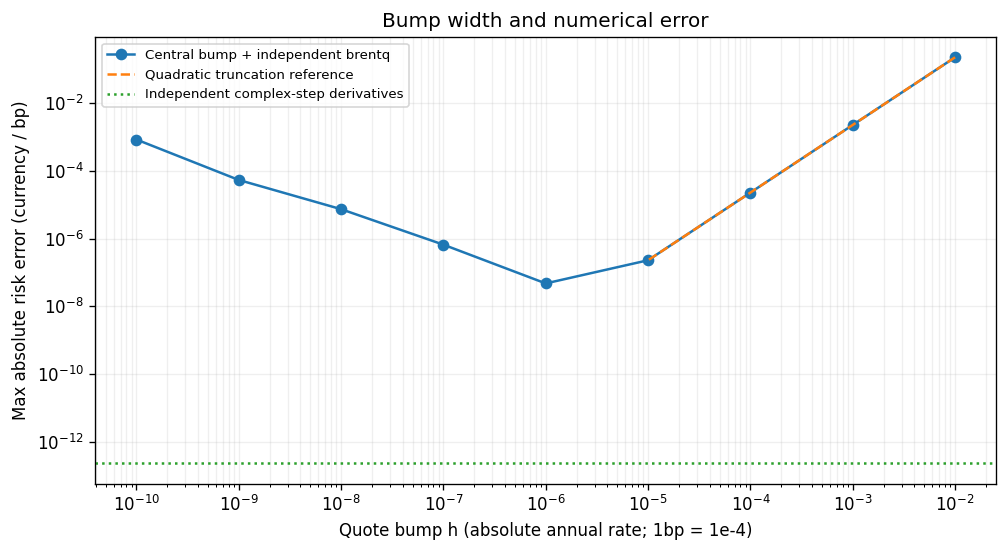

In [3]:
bump = data["bump"]
h = np.array(bump["widths"])
errors = np.array(bump["max_abs_error_per_bp"])
fig, ax = plt.subplots(figsize=(8.5, 4.7))
ax.loglog(h, np.maximum(errors, 1e-14), "o-", label="Central bump + independent brentq")
ax.loglog(h[:4], errors[0] * (h[:4] / h[0])**2, "--", label="Quadratic truncation reference")
cs = max(bump["complex_step_max_abs_error_per_bp"], 1e-14)
ax.axhline(cs, color="tab:green", linestyle=":", label="Independent complex-step derivatives")
ax.set_xlabel("Quote bump h (absolute annual rate; 1bp = 1e-4)")
ax.set_ylabel("Max absolute risk error (currency / bp)")
ax.set_title("Bump width and numerical error")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.2)
fig.tight_layout()
plt.show()


## 3. 柱を裏付ける商品が乏しいと何が起きるか

柱を0.5・1・2・3・5年で固定したまま、最後のスワップの満期を3年へ近づける。
5年の柱を決める情報が薄くなり、クオート1bpに対するzeroの変化が増幅される。
3年と最後のクオートの感応度は大きくなって互いに打ち消し合う。
合計が小さいことだけでは、安定した較正と判断できない。

**警告：zero bp / quote bp の最大増幅率が10超。** 10はこの研究の設計値。
残差・座標の単位を変えると生の条件数も変わるため、それだけで拒否しない。
数値的rank欠落では停止し、感応度を返さない。


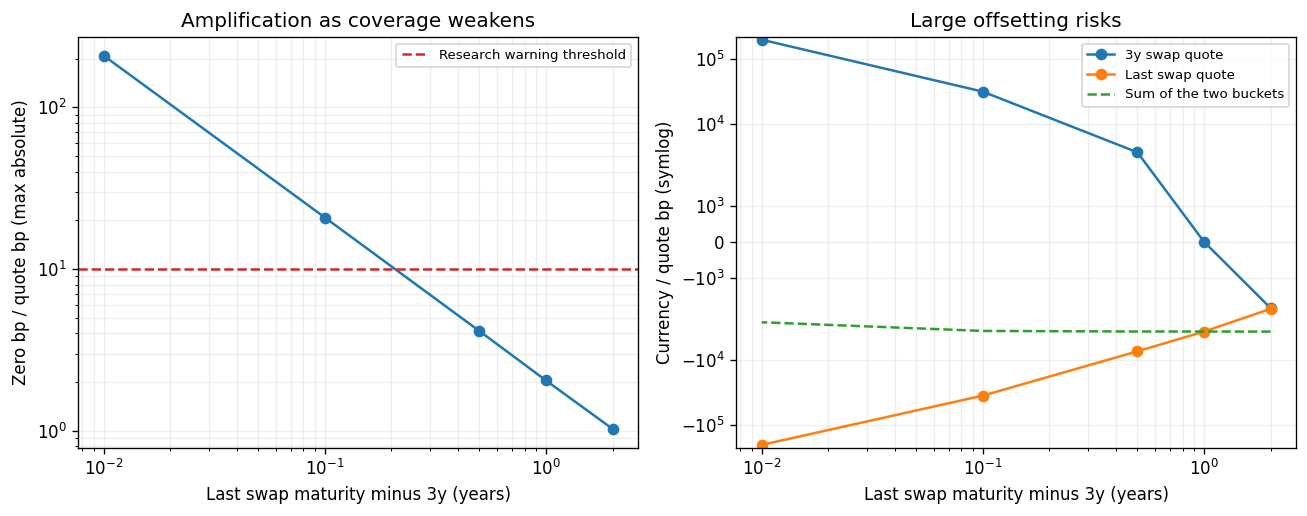

満期を3年に一致させた場合：`calibration Jacobian is numerically rank deficient or singular`。

In [4]:
coverage = data["coverage"]
gap = np.array([c["last_swap_maturity"] - 3 for c in coverage])
amplification = np.array([c["amplification"] for c in coverage])
risks = np.array([c["quote_risk_per_bp"] for c in coverage])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].loglog(gap, amplification, "o-")
axes[0].axhline(10, color="tab:red", linestyle="--", label="Research warning threshold")
axes[0].set_ylabel("Zero bp / quote bp (max absolute)")
axes[0].set_title("Amplification as coverage weakens")
axes[0].legend(fontsize=8)
axes[1].plot(gap, risks[:, 3], "o-", label="3y swap quote")
axes[1].plot(gap, risks[:, 4], "o-", label="Last swap quote")
axes[1].plot(gap, risks[:, 3] + risks[:, 4], "--", label="Sum of the two buckets")
axes[1].set_xscale("log")
axes[1].set_yscale("symlog", linthresh=2000)
axes[1].set_ylabel("Currency / quote bp (symlog)")
axes[1].set_title("Large offsetting risks")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("Last swap maturity minus 3y (years)")
    ax.grid(True, which="both", alpha=0.2)
fig.tight_layout()
plt.show()
display(Markdown("満期を3年に一致させた場合：`" + data["singular_pillar_rejection"] + "`。"))


## 追加検算：座標・残差・補間・Hullの表

zeroとlog DFの**座標変更**では、クオート感応度は同じ、パラメータ感応度は異なる。
クオート残差とPV残差の**書き換え**も、同じ根の正しい微分ならクオート感応度は同じ。
一方、zero線形からlog DF線形への**補間規約の変更**はモデル変更で、PVとリスクの配分を変える。
このfixtureで合計が近いことを、補間に対する不変性として一般化しない。

Hull 11e GE Table4.3の債券価格は既存の独立bootstrapで照合する。
債券の価格クオートの感応度は **通貨 / 価格1.00** で、金利の **通貨 / 1bp** と混ぜない。


In [5]:
alt = data["logdf_interpolation"]
rows = ["|補間|PV|クオート感応度の合計 / bp|", "|---|---:|---:|"]
for label, case in [("zero線形", base), ("log DF線形", alt)]:
    rows.append(f"|{label}|{case['pv']:,.2f}|{sum(case['quote_risk_per_bp']):,.6f}|")
display(Markdown("\n".join(rows)))
table = data["hull_table_4_3"]
display(Markdown(f"Table4.3のbootstrap zero最大差：{table['bootstrap_max_abs_zero_error']:.2e}。"
                 f"1.75年割引債100万の価格クオート感応度："
                 + ", ".join(f"{r:,.3f}" for r in table["quote_risk_per_price_1"])))


|補間|PV|クオート感応度の合計 / bp|
|---|---:|---:|
|zero線形|-2,980,843.07|-3,233.038188|
|log DF線形|-2,986,256.89|-3,231.577672|

Table4.3のbootstrap zero最大差：1.49e-16。1.75年割引債100万の価格クオート感応度：-0.000, -218.967, -218.967, 5,574.455, 4,299.115

## 次に広げる場合

v2（過剰決定・最小二乗）とv3（HW1F swaption較正）は別承認。
残差がゼロでない最小二乗解で、v1の逆Jacobianをそのまま流用しない。
公開API・本編Book/portal・節の正式台帳への登録はこの研究の範囲に含めない。
